# AI SQL Data Analyst Agent (CSV → SQL → Insights)

Step-by-step implementation

In [1]:
import pandas as pd
import sqlite3

In [2]:
# Load your CSV file
df = pd.read_csv("data.csv")
df.head()

,region,sales
0,North,100
1,South,150
2,East,200
3,West,130
4,North,170


In [3]:
# Save to SQLite
conn = sqlite3.connect("data.db")
df.to_sql("data_table", conn, if_exists="replace", index=False)

print("Data saved to SQLite!")

Data saved to SQLite!


In [4]:
!pip install requests==2.32.4

In [9]:
!pip install langchain==0.2.14 langchain-community==0.2.12 langchain-groq==0.1.9 requests==2.32.4

  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.8/997.8 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 75.7 MB/s eta 0:00:00
Using cached requests-2.32.4-py3-none-any.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.1.4
    Uninstalling tenacity-9.1.4:
      Successfully uninstalled tenacity-9.1.4
  Attempting uninstall: requests
    Found existing installation: requests 2.33.1
    Uninstalling requests-2.33.1:
      Successfully uninstalled requests-2.33.1


In [ ]:
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import create_sql_agent
from langchain.agents import AgentType
from langchain_groq import ChatGroq

# Connect database
db = SQLDatabase.from_uri("sqlite:///data.db")

# LLM
llm = ChatGroq(
    model="llama-3.1-8b-instant",   # safer & faster
    api_key="gsk_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

)

# Create agent
agent = create_sql_agent(
    llm=llm,
    db=db,
    agent_type=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)


In [5]:
# Ask a question
query = "What is the average sales per region?"
response = agent.invoke({"input": query})
print(response)




> Entering new SQL Agent Executor chain...
Question: What is the average sales per region?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: data_tableQuestion: What is the average sales per region?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: data_tableQuestion: What is the average sales per region?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: data_tableQuestion: What is the average sales per region?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: data_tableQue

In [6]:
# Get detailed response (including SQL reasoning)
result = agent.invoke({"input": query})
result



> Entering new SQL Agent Executor chain...
Question: What is the average sales per region?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: data_tableQuestion: What is the average sales per region?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: data_tableQuestion: What is the average sales per region?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: data_tableQuestion: What is the average sales per region?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: data_tableQue

{'input': 'What is the average sales per region?',
 'output': 'Agent stopped due to iteration limit or time limit.'}

In [9]:
import sqlite3

conn = sqlite3.connect("data.db")

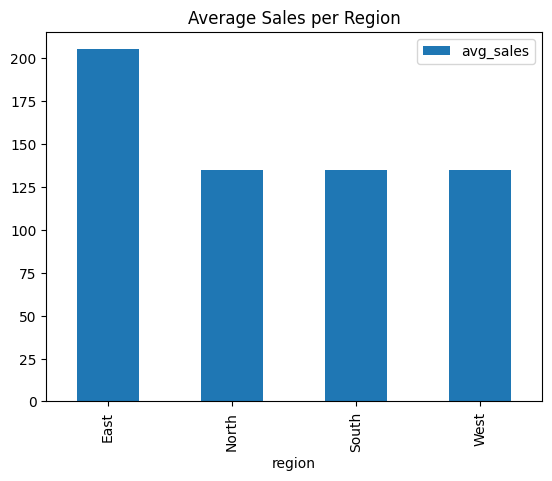

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

df_result = pd.read_sql_query(
    "SELECT region, AVG(sales) as avg_sales FROM data_table GROUP BY region",
    conn
)

df_result.plot(kind="bar", x="region", y="avg_sales")
plt.title("Average Sales per Region")
plt.show()